In [1]:
import pandas as pd

In [2]:
df1 = pd.read_csv('../benchmark_runs/run_20260204_234029/run_summary.csv')
df2 = pd.read_csv('../benchmark_runs/run_20260212_122428/run_summary.csv')
df3 = pd.read_csv('../benchmark_runs/run_20260216_013728/run_summary.csv')

In [3]:
df = pd.concat([df1, df2, df3], ignore_index=True)
df = df.drop_duplicates(subset=['config_file'])

In [4]:
df.columns

Index(['config_file', 'target_id', 'pdb_id', 'doc_id', 'assay_id',
       'fragment_smiles', 'status', 'n_compounds_total',
       'n_compounds_standardized', 'n_compounds_matched_2d',
       'n_compounds_docked', 'n_conformers_docked', 'n_valid_poses',
       'runtime_seconds', 'success_rate_2d', 'success_rate_rmsd',
       'workflow_key', 'best_any_n_points', 'best_any_pearson',
       'best_any_spearman', 'best_any_r2', 'rmsd_n_points', 'rmsd_pearson',
       'rmsd_spearman', 'rmsd_r2'],
      dtype='str')

In [4]:
# Count how many entries there are for each status in the DataFrame
counts = df['status'].value_counts()
percentages = df['status'].value_counts(normalize=True) * 100
result = pd.DataFrame({'count': counts, 'percentage': percentages.round(2)})
print(result)

                  count  percentage
status                             
SUCCESS            7640       98.05
FAILED_GRID_PREP    151        1.94
FAILED_DOCKING        1        0.01


In [5]:
df_success = df[df['status'] == 'SUCCESS'].reset_index(drop=True)
df_success

,config_file,target_id,pdb_id,doc_id,assay_id,fragment_smiles,status,n_compounds_total,n_compounds_standardized,n_compounds_matched_2d,...,success_rate_rmsd,workflow_key,best_any_n_points,best_any_pearson,best_any_spearman,best_any_r2,rmsd_n_points,rmsd_pearson,rmsd_spearman,rmsd_r2
0,generated_configs/CHEMBL1781_1K4T_CHEMBL112679...,CHEMBL1781,1K4T,CHEMBL1126797,CHEMBL873882,O=C1C=CC=C2C3=NC4=C(C=CC=C4)C=C3CN12,SUCCESS,49,49,49,...,0.00,CHEMBL1781_1K4T_CHEMBL1126797_CHEMBL873882,49.0,-0.055652,-0.065830,0.003097,NaN,NaN,NaN,NaN
1,generated_configs/CHEMBL1781_1RR8_CHEMBL112679...,CHEMBL1781,1RR8,CHEMBL1126797,CHEMBL873882,O=C1C=CC=C2C3=NC4=C(C=CC=C4)C=C3CN12,SUCCESS,49,49,49,...,0.00,CHEMBL1781_1RR8_CHEMBL1126797_CHEMBL873882,49.0,-0.017715,0.050810,0.000314,NaN,NaN,NaN,NaN
2,generated_configs/CHEMBL1781_1T8I_CHEMBL112679...,CHEMBL1781,1T8I,CHEMBL1126797,CHEMBL873882,O=C1C=CC=C2C3=NC4=C(C=CC=C4)C=C3CN12,SUCCESS,49,49,49,...,0.00,CHEMBL1781_1T8I_CHEMBL1126797_CHEMBL873882,49.0,0.027770,0.049911,0.000771,NaN,NaN,NaN,NaN
3,generated_configs/CHEMBL1782_1YQ7_CHEMBL114590...,CHEMBL1782,1YQ7,CHEMBL1145906,CHEMBL681890,O=P(O)(O)CP(=O)(O)O,SUCCESS,61,61,61,...,8.22,CHEMBL1782_1YQ7_CHEMBL1145906_CHEMBL681890,61.0,-0.240730,-0.299628,0.057951,17.0,-0.076934,-0.056442,0.005919
4,generated_configs/CHEMBL1782_1YV5_CHEMBL114590...,CHEMBL1782,1YV5,CHEMBL1145906,CHEMBL681890,O=P(O)(O)CP(=O)(O)O,SUCCESS,61,61,61,...,10.96,CHEMBL1782_1YV5_CHEMBL1145906_CHEMBL681890,61.0,-0.163363,-0.167154,0.026687,23.0,0.118262,0.067507,0.013986
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7635,generated_configs/CHEMBL5491_5V5Y_CHEMBL572898...,CHEMBL5491,5V5Y,CHEMBL5728983,CHEMBL5737854,O=C1NNC2=NC=NC=C12,SUCCESS,65,65,62,...,45.04,CHEMBL5491_5V5Y_CHEMBL5728983_CHEMBL5737854,62.0,0.059886,0.088437,0.003586,61.0,0.049462,0.086614,0.002447
7636,generated_configs/CHEMBL5491_5VC5_CHEMBL114351...,CHEMBL5491,5VC5,CHEMBL1143513,CHEMBL829373,CN1C(=O)C(C2=CC=CC=C2)=CC2=CN=C(NC3=CC=CC=C3)N...,SUCCESS,48,48,48,...,68.75,CHEMBL5491_5VC5_CHEMBL1143513_CHEMBL829373,48.0,-0.605210,-0.603427,0.366279,48.0,-0.608624,-0.607157,0.370424
7637,generated_configs/CHEMBL5491_7N3U_CHEMBL484236...,CHEMBL5491,7N3U,CHEMBL4842364,CHEMBL4844304,C1=CC=C(NC2=NC=CC=N2)C=C1,SUCCESS,31,31,30,...,32.50,CHEMBL5491_7N3U_CHEMBL4842364_CHEMBL4844304,30.0,0.102701,0.190275,0.010547,28.0,-0.039918,0.055022,0.001593
7638,generated_configs/CHEMBL5491_8BJU_CHEMBL525713...,CHEMBL5491,8BJU,CHEMBL5257134,CHEMBL5260351,CNC1=CC=CC=C1,SUCCESS,49,49,49,...,21.43,CHEMBL5491_8BJU_CHEMBL5257134_CHEMBL5260351,49.0,-0.177157,-0.178298,0.031385,31.0,-0.277599,-0.265638,0.077061


In [6]:
num_below_30 = (df_success['n_compounds_matched_2d'] < 30).sum()
print("Number of rows with n_compounds_matched_2d below 30:", num_below_30)
num_below_20 = (df_success['n_compounds_matched_2d'] < 20).sum()
print("Number of rows with n_compounds_matched_2d below 20:", num_below_20)

Number of rows with n_compounds_matched_2d below 30: 4328
Number of rows with n_compounds_matched_2d below 20: 472


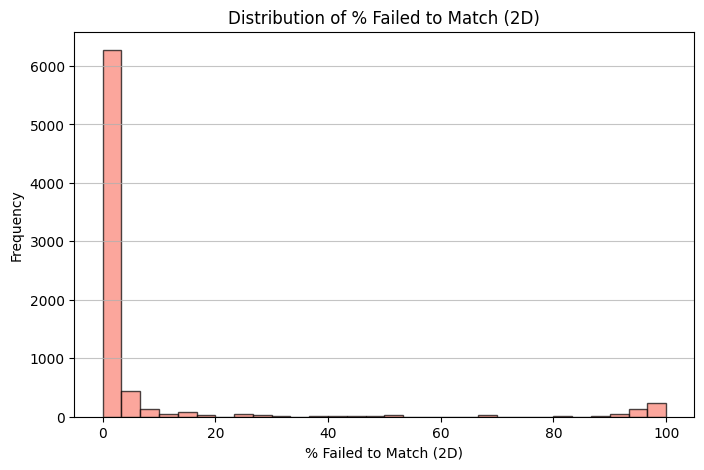

In [11]:
# Calculate the percentage of compounds that failed to match for each row
df_success['pct_failed_to_match'] = 100 * (
    (df_success['n_compounds_standardized'] - df_success['n_compounds_matched_2d']) 
    / df_success['n_compounds_standardized']
)

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
df_success['pct_failed_to_match'].dropna().plot(
    kind='hist', bins=30, alpha=0.7, color='salmon', edgecolor='black'
)
plt.title('Distribution of % Failed to Match (2D)')
plt.xlabel('% Failed to Match (2D)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

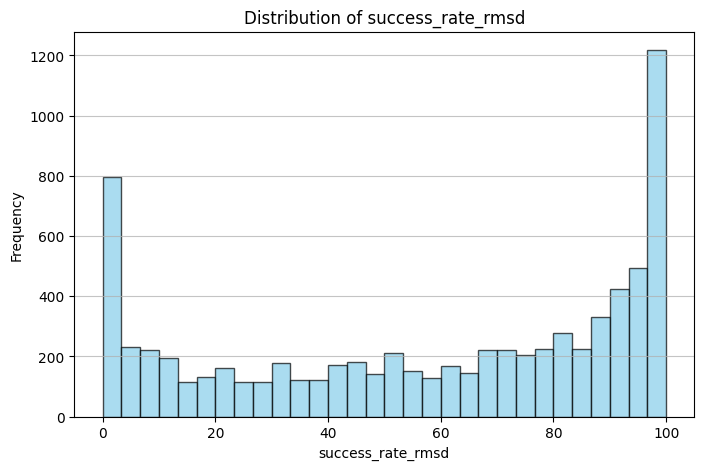

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
df_success['success_rate_rmsd'].plot(kind='hist', bins=30, alpha=0.7, color='skyblue', edgecolor='black')
plt.title('Distribution of success_rate_rmsd')
plt.xlabel('success_rate_rmsd')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

In [23]:
df_high_success = df_success[(df_success['success_rate_rmsd'] > 75.0) & (df_success['n_compounds_matched_2d'] > 20)]
len(df_high_success)

3045

In [24]:
df_high_success.columns


Index(['config_file', 'target_id', 'pdb_id', 'doc_id', 'assay_id',
       'fragment_smiles', 'status', 'n_compounds_total',
       'n_compounds_standardized', 'n_compounds_matched_2d',
       'n_compounds_docked', 'n_conformers_docked', 'n_valid_poses',
       'runtime_seconds', 'success_rate_2d', 'success_rate_rmsd',
       'workflow_key', 'best_any_n_points', 'best_any_pearson',
       'best_any_spearman', 'best_any_r2', 'rmsd_n_points', 'rmsd_pearson',
       'rmsd_spearman', 'rmsd_r2', 'pct_failed_to_match'],
      dtype='str')

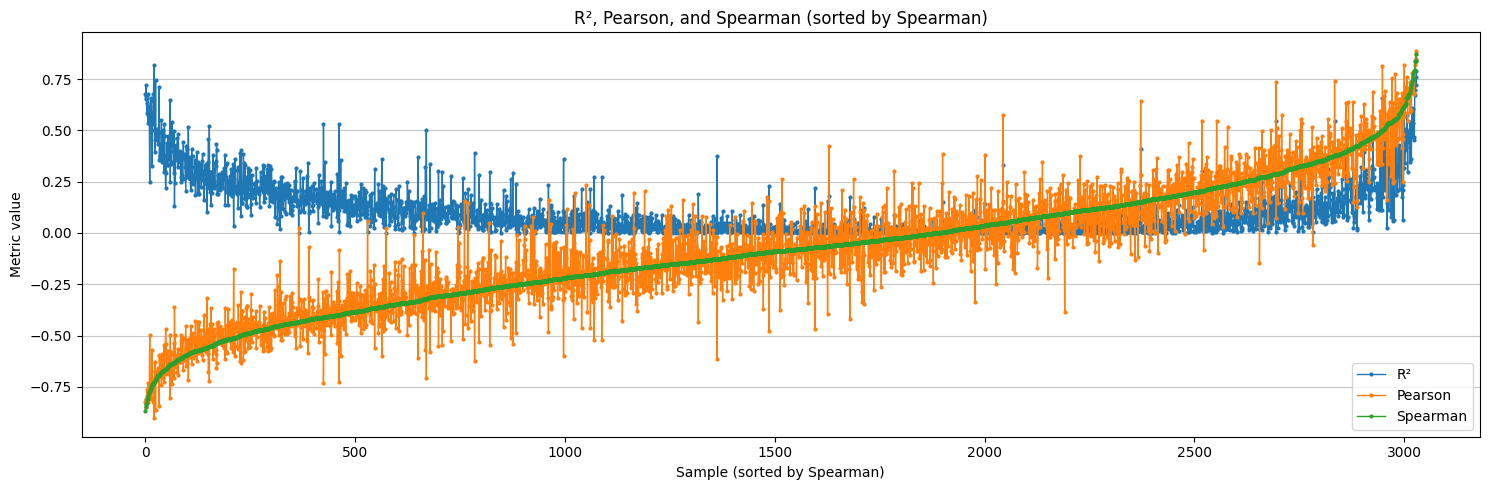

In [25]:
import matplotlib.pyplot as plt

# Sort the DataFrame by 'rmsd_spearman' ascending
metrics = ['rmsd_r2', 'rmsd_pearson', 'rmsd_spearman']
titles = ['R²', 'Pearson', 'Spearman']

df_sorted = df_high_success.sort_values(by='rmsd_spearman', ascending=True)

plt.figure(figsize=(15, 5))
for metric, title in zip(metrics, titles):
    values = df_sorted[metric].dropna().values
    plt.plot(range(len(values)), values, marker='o', linestyle='-', linewidth=1, markersize=2, label=title)
plt.title('R², Pearson, and Spearman (sorted by Spearman)')
plt.xlabel('Sample (sorted by Spearman)')
plt.ylabel('Metric value')
plt.legend()
plt.grid(axis='y', alpha=0.7)
plt.tight_layout()
plt.show()

In [29]:
df_sorted.head(30).to_csv('best_pl_systems.csv', index=False)